## Notebook 10 — Water-balance implications of AET method choice

**Why this matters:** in the NPS WBM's bucket structure, actual evapotranspiration
(AET) is the model's primary *outflow* competing with runoff generation. Concretely
(see `wbm/snow_soil.py`): each day, `storage_add = W - AET - dSOIL` (where `W` is rain
+ snowmelt reaching the soil), and `RUNOFF = storage_release(storage_add) + direct_frac
* RAIN`. Higher AET means less water left over for storage release, so **at the
annual-to-multiyear scale, underestimating AET directly inflates the WBM's runoff
estimate** (soil-moisture and snowpack carry-over roughly net to zero over several
years, so `RUNOFF ≈ PPT - AET` is a good long-run approximation, and this notebook
checks that against the model's own literal `RUNOFF` output rather than assuming it).

Notebooks 04/07/08 established that **default (uncalibrated) Oudin systematically
underestimates AET** relative to OpenET and flux towers, and that per-site- and
per-ecosystem-calibrated Oudin and Penman-Monteith (default and Kc-calibrated) all
correct much of that bias to varying degrees. This notebook asks the practical
follow-on question across the same **six-variant** comparison used in notebook 08:
**if the WBM is currently being run with uncalibrated Oudin, how much is its runoff
estimate being inflated as a result — and how much of that gets corrected by each
alternative?**

A second question, addressed in the "Seasonality" section below: **is that
runoff-overestimation bias spread evenly across the year, or concentrated in
particular months?** AET's share of the water balance varies seasonally (e.g. low in
winter when little water is available for ET, high in the growing season), so a
temperature-based method's AET bias plausibly does too — and if the biggest bias
lines up with the months that already generate the most runoff (e.g. snowmelt), the
annual-total framing above could be masking a much larger practical error at the
specific times of year that matter most for downstream water availability.

**A note on staleness detection:** the load cell below automatically checks whether
the two Penman-Monteith Kc-calibrated caches (notebook 07's per-site and
per-ecosystem fits) are newer than the current gridMET climate cache, since notebook
07's incremental per-site caching only checks whether a site's *name* is already
present, not whether the climate data it was fit against has changed — a real gap
that briefly left this notebook's PM-Kc variants stale after a gridMET wind-data
refetch earlier in this project. Notebook 07 has since been re-run with fresh caches,
so all six variants below are currently included; if that check ever prints a WARNING
or NOTE again in the future, treat the flagged variant(s) as untrustworthy until
notebook 07 is re-run.

This is a read-only analysis: it reuses the full 2016–2023 daily WBM outputs already
cached by notebooks 03 (default Oudin), 04 (per-site/per-ecosystem-calibrated Oudin),
06 (Penman-Monteith), and 07 (per-site/per-ecosystem Kc-calibrated Penman-Monteith) —
no new WBM runs, no GEE access. `RUNOFF` is already a per-day output column in each of
those caches, so this notebook just aggregates and compares it directly, rather than
re-deriving it from `PPT - AET`.

**Prerequisites:** run notebooks 01→02→03 at least once (default Oudin WBM cache),
notebook 04 at least once (`wbm_results_site_cal_{OBJECTIVE}.csv` and
`wbm_results_ecosystem_cal_{OBJECTIVE}.csv`), notebook 06 at least once
(`wbm_results_penman_monteith.csv`), and notebook 07 at least once
(`wbm_results_site_cal_pm_{OBJECTIVE}.csv` and
`wbm_results_ecosystem_cal_pm_{OBJECTIVE}.csv`).

# Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
os.makedirs("../Data/runoff_implications", exist_ok=True)
print("Imports OK -- this notebook only reads cached CSVs, no GEE/WBM run needed.")

Imports OK -- this notebook only reads cached CSVs, no GEE/WBM run needed.


### Load cached full-period WBM outputs (default Oudin, per-site-calibrated Oudin, Penman-Monteith)

All three caches store fluxes in **inches** (the repo's default `TO_INCHES = True`),
despite the `_mm`-suffixed column names -- converted to mm here (`x 25.4`) to match the
units used everywhere else in this project's reports.

In [2]:
IN_TO_MM = 25.4
COLS = ["date", "site", "ecosystem", "state", "ppt_mm", "AET", "RUNOFF"]

with open("../Data/gridmet_cache/last_objective.txt") as f:
    CAL_OBJECTIVE = f.read().strip()
with open("../Data/gridmet_cache/last_objective_pm.txt") as f:
    CAL_OBJECTIVE_PM = f.read().strip()
if CAL_OBJECTIVE_PM != CAL_OBJECTIVE:
    print(f"WARNING -- Oudin calibration objective ('{CAL_OBJECTIVE}') and Penman-Monteith "
          f"Kc calibration objective ('{CAL_OBJECTIVE_PM}') differ -- the calibrated "
          "variants below are not using the same objective function (same check as "
          "notebook 08's banner).")

# Six variants, matching notebook 08's comparison exactly.
VARIANT_FILES = {
    "default":  "wbm_results_flux_towers_2016_2023.csv",
    "sitecal":  f"wbm_results_site_cal_{CAL_OBJECTIVE}.csv",
    "ecocal":   f"wbm_results_ecosystem_cal_{CAL_OBJECTIVE}.csv",
    "pm":       "wbm_results_penman_monteith.csv",
    "pmcal":    f"wbm_results_site_cal_pm_{CAL_OBJECTIVE_PM}.csv",
    "pmecocal": f"wbm_results_ecosystem_cal_pm_{CAL_OBJECTIVE_PM}.csv",
}
VARIANT_LABELS = {
    "default":  "Oudin (default)",
    "sitecal":  f"Oudin (per-site calibrated, {CAL_OBJECTIVE})",
    "ecocal":   f"Oudin (per-ecosystem calibrated, {CAL_OBJECTIVE})",
    "pm":       "Penman-Monteith (default)",
    "pmcal":    f"Penman-Monteith (per-site Kc calibrated, {CAL_OBJECTIVE_PM})",
    "pmecocal": f"Penman-Monteith (per-ecosystem Kc calibrated, {CAL_OBJECTIVE_PM})",
}
ALT_COLORS = {
    "sitecal":  "seagreen",
    "ecocal":   "goldenrod",
    "pm":       "tomato",
    "pmcal":    "mediumpurple",
    "pmecocal": "slategrey",
}

# All caches store fluxes in inches (the repo's default TO_INCHES = True), despite the
# _mm-suffixed column names -- converted to mm here (x 25.4) to match units used
# elsewhere in this project's reports.
#
# Auto-detect missing/stale PM-Kc-calibrated caches: Oudin never uses wind, so its
# calibrated variants (sitecal/ecocal) are safe regardless of when they were last
# (re)run. Penman-Monteith's Kc calibration (notebook 07) DOES depend on wind -- and
# its incremental caching only checks site PRESENCE, not whether the underlying
# climate data changed, so it silently skipped re-fitting after the gridMET wind-data
# refetch earlier in this project. Two possible states here: (a) the stale cache
# still exists (file timestamp predates the climate refetch) or (b) it's been deleted
# in preparation for re-running notebook 07 (file doesn't exist yet). Either way,
# exclude it from every comparison below until a fresh cache appears.
CLIMATE_PATH = "../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv"
_climate_mtime = os.path.getmtime(CLIMATE_PATH) if os.path.exists(CLIMATE_PATH) else 0

wbm = {}
ALTERNATIVES = ["sitecal", "ecocal", "pm"]  # always trustworthy (Oudin has no wind dependency)
for key, fname in VARIANT_FILES.items():
    fpath = f"../Data/gridmet_cache/{fname}"

    if key in ("pmcal", "pmecocal"):
        if not os.path.exists(fpath):
            print(f"\nNOTE -- '{VARIANT_LABELS[key]}' cache ({fname}) not found -- looks "
                  "like it's been deleted in preparation for re-running notebook 07. Excluded "
                  "from every comparison below until a fresh cache is generated; just re-run "
                  "this notebook afterward and it will be picked up automatically.")
            continue
        if os.path.getmtime(fpath) < _climate_mtime:
            print(f"\nWARNING -- '{VARIANT_LABELS[key]}' cache ({fname}) predates the "
                  f"current gridMET climate data ({CLIMATE_PATH}) -- notebook 07's "
                  "incremental per-site caching silently skipped re-fitting Kc after the "
                  "wind-data refetch (it only checks site presence, not whether the climate "
                  "data changed). EXCLUDED from every comparison below until notebook 07 is "
                  "re-run with its stale caches (kc_site_*.csv, kc_ecosystem_*.csv, "
                  "wbm_results_(site|ecosystem)_cal_pm_*.csv, "
                  "wbm_monthly_(site|ecosystem)_cal_pm_*.csv) deleted first.")
            continue
        ALTERNATIVES.append(key)

    df = pd.read_csv(fpath, usecols=COLS, parse_dates=["date"])
    for c in ("ppt_mm", "AET", "RUNOFF"):
        df[c] = df[c] * IN_TO_MM
    wbm[key] = df
    print(f"{key:10s} ({VARIANT_LABELS[key]:58s}): {df.shape}")

print(f"\nVariants included in this run's comparisons: {ALTERNATIVES}")

default    (Oudin (default)                                           ): (236601, 7)


sitecal    (Oudin (per-site calibrated, peak_nse)                     ): (210312, 7)


ecocal     (Oudin (per-ecosystem calibrated, peak_nse)                ): (210312, 7)


pm         (Penman-Monteith (default)                                 ): (236601, 7)


pmcal      (Penman-Monteith (per-site Kc calibrated, peak_nse)        ): (210312, 7)


pmecocal   (Penman-Monteith (per-ecosystem Kc calibrated, peak_nse)   ): (210312, 7)

Variants included in this run's comparisons: ['sitecal', 'ecocal', 'pm', 'pmcal', 'pmecocal']


### Aggregate to mean annual water balance per site

Sum daily `ppt_mm` / `AET` / `RUNOFF` to calendar-year totals per site, then average
across all available years -- this is the "typical annual water balance" each variant
implies at each site.

In [3]:
def mean_annual_balance(df, label):
    """Calendar-year sums per site, then averaged across years -> one row per site."""
    yearly = (
        df.assign(year=df["date"].dt.year)
        .groupby(["site", "year"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .sum()
    )
    out = (
        yearly.groupby("site", as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .mean()
        .rename(columns={
            "ppt_mm": f"ppt_{label}", "AET": f"aet_{label}", "RUNOFF": f"runoff_{label}",
        })
    )
    return out


ann = {key: mean_annual_balance(df, key) for key, df in wbm.items()}
eco_lookup = wbm["default"][["site", "ecosystem", "state"]].drop_duplicates()

balance = ann["default"]
for key in ALTERNATIVES:
    balance = balance.merge(ann[key], on="site", how="inner")
balance = balance.merge(eco_lookup, on="site", how="left")

# Sanity check: RUNOFF ~ PPT - AET at the multi-year mean scale (storage/snowpack
# carry-over should mostly net out over 8 years) -- this is NOT assumed anywhere
# above, just checked here against the model's own literal RUNOFF output. Only
# checked for variants actually included below (ALTERNATIVES already excludes any
# stale PM-Kc cache -- see the WARNING printed in the load cell above).
for label in ["default"] + ALTERNATIVES:
    resid = (balance[f"ppt_{label}"] - balance[f"aet_{label}"]) - balance[f"runoff_{label}"]
    print(f"{label:10s}: PPT - AET vs RUNOFF, mean residual = {resid.mean():+.1f} mm/yr "
          f"(median abs residual = {resid.abs().median():.1f} mm/yr, n={len(balance)} sites)")

print(f"\nSites with all {1 + len(ALTERNATIVES)} included variants matched: {len(balance)}")
balance.to_csv("../Data/runoff_implications/annual_water_balance_by_site.csv", index=False)

default   : PPT - AET vs RUNOFF, mean residual = +16.3 mm/yr (median abs residual = 3.0 mm/yr, n=72 sites)
sitecal   : PPT - AET vs RUNOFF, mean residual = +16.0 mm/yr (median abs residual = 3.7 mm/yr, n=72 sites)
ecocal    : PPT - AET vs RUNOFF, mean residual = +16.5 mm/yr (median abs residual = 3.1 mm/yr, n=72 sites)
pm        : PPT - AET vs RUNOFF, mean residual = +16.0 mm/yr (median abs residual = 4.1 mm/yr, n=72 sites)
pmcal     : PPT - AET vs RUNOFF, mean residual = +15.3 mm/yr (median abs residual = 3.4 mm/yr, n=72 sites)
pmecocal  : PPT - AET vs RUNOFF, mean residual = +17.3 mm/yr (median abs residual = 2.4 mm/yr, n=72 sites)

Sites with all 6 included variants matched: 72


### How much is uncalibrated Oudin currently overestimating runoff?

`delta_runoff = runoff_default - runoff_{alternative}` is how much runoff would
**decrease** (i.e. how much the current uncalibrated-Oudin estimate is being
**overestimated**) if the WBM switched to that alternative. Reported both in mm/year and
as a percentage of the alternative's own runoff estimate (a natural "how far off is the
status quo" framing) and as a percentage of mean annual precipitation (a scale-free
comparison across sites with very different climates).

In [4]:
# "% of the alternative's own runoff estimate" is a natural "how far off is the status
# quo" framing, but blows up at sites where the alternative's runoff is itself near
# zero (e.g. very dry sites) -- restrict that specific ratio to sites with a
# meaningfully nonzero denominator (>= 10 mm/yr) so a handful of near-zero-runoff sites
# don't dominate the mean. The %-of-precipitation version below has no such issue
# (precipitation is never near zero) and is reported for all sites.
RUNOFF_FLOOR = 10.0  # mm/yr

for alt in ALTERNATIVES:
    balance[f"delta_runoff_{alt}"] = balance["runoff_default"] - balance[f"runoff_{alt}"]
    balance[f"pct_overest_{alt}_of_runoff"] = np.where(
        balance[f"runoff_{alt}"] >= RUNOFF_FLOOR,
        100 * balance[f"delta_runoff_{alt}"] / balance[f"runoff_{alt}"],
        np.nan,
    )
    balance[f"pct_overest_{alt}_of_ppt"] = (
        100 * balance[f"delta_runoff_{alt}"] / balance["ppt_default"].replace(0, np.nan)
    )

print("── Nationwide: how much does uncalibrated-Oudin runoff shrink if switched? ──")
for alt in ALTERNATIVES:
    label = VARIANT_LABELS[alt]
    d_mm   = balance[f"delta_runoff_{alt}"]
    d_pctR = balance[f"pct_overest_{alt}_of_runoff"].dropna()
    d_pctP = balance[f"pct_overest_{alt}_of_ppt"]
    n_excluded = balance[f"runoff_{alt}"].lt(RUNOFF_FLOOR).sum()
    print(f"\nSwitch default Oudin -> {label}:")
    print(f"  mean  Δrunoff = {d_mm.mean():+7.1f} mm/yr   "
          f"median Δrunoff = {d_mm.median():+7.1f} mm/yr")
    print(f"  mean  overestimate = {d_pctR.mean():+6.1f}% of the {label} runoff estimate  "
          f"(median = {d_pctR.median():+6.1f}%, {n_excluded} near-zero-runoff site(s) excluded)")
    print(f"  mean  overestimate = {d_pctP.mean():+6.1f}% of mean annual precip  "
          f"(median = {d_pctP.median():+6.1f}%)")

balance.to_csv("../Data/runoff_implications/annual_water_balance_by_site.csv", index=False)
print("\nSaved to Data/runoff_implications/annual_water_balance_by_site.csv")

── Nationwide: how much does uncalibrated-Oudin runoff shrink if switched? ──

Switch default Oudin -> Oudin (per-site calibrated, peak_nse):
  mean  Δrunoff =  +129.2 mm/yr   median Δrunoff =   +64.7 mm/yr
  mean  overestimate =  +87.5% of the Oudin (per-site calibrated, peak_nse) runoff estimate  (median =  +52.0%, 27 near-zero-runoff site(s) excluded)
  mean  overestimate =  +15.7% of mean annual precip  (median =   +7.7%)

Switch default Oudin -> Oudin (per-ecosystem calibrated, peak_nse):
  mean  Δrunoff =  +128.4 mm/yr   median Δrunoff =   +58.1 mm/yr
  mean  overestimate = +279.8% of the Oudin (per-ecosystem calibrated, peak_nse) runoff estimate  (median =  +55.0%, 30 near-zero-runoff site(s) excluded)
  mean  overestimate =  +16.2% of mean annual precip  (median =  +12.4%)

Switch default Oudin -> Penman-Monteith (default):
  mean  Δrunoff =  +218.8 mm/yr   median Δrunoff =  +145.9 mm/yr
  mean  overestimate = +482.2% of the Penman-Monteith (default) runoff estimate  (median = 

### By ecosystem

        ecosystem  ppt_default  aet_default  aet_sitecal  aet_ecocal  aet_pm  aet_pmcal  aet_pmecocal  runoff_default  runoff_sitecal  runoff_ecocal  runoff_pm  runoff_pmcal  runoff_pmecocal  delta_runoff_sitecal  delta_runoff_ecocal  delta_runoff_pm  delta_runoff_pmcal  delta_runoff_pmecocal  pct_overest_sitecal_of_ppt  pct_overest_ecocal_of_ppt  pct_overest_pm_of_ppt  pct_overest_pmcal_of_ppt  pct_overest_pmecocal_of_ppt  n_sites
        Croplands        605.9        299.8        422.2       385.6   505.0      458.9         436.0           303.8           181.1          218.2       98.7         144.5            167.2                 122.7                 85.6            205.0               159.3                  136.6                        14.3                        9.7                   23.8                      17.6                         17.7       40
       Grasslands        621.7        229.2        410.9       413.2   488.8      457.6         459.2           364.6           

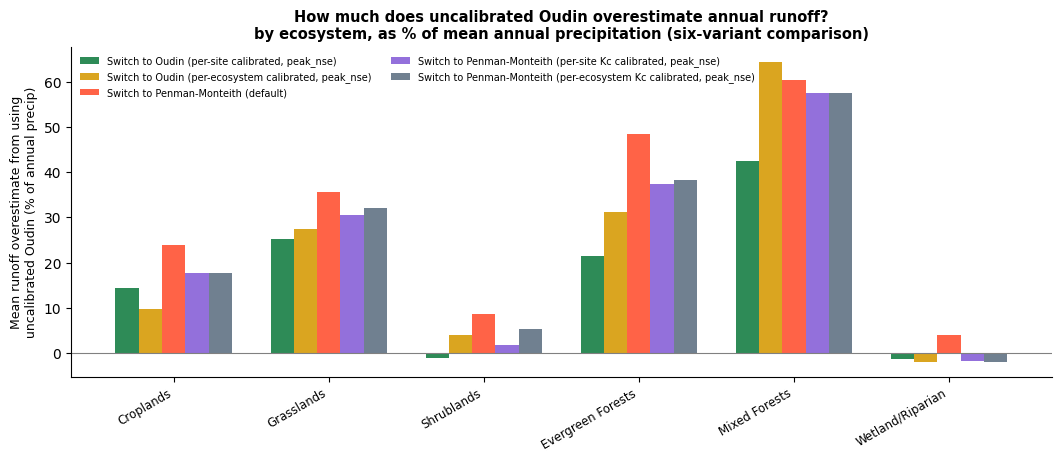

Saved to Data/runoff_implications/runoff_overestimate_by_ecosystem.png


In [5]:
_included = ["default"] + ALTERNATIVES  # only variants actually merged into `balance`
eco_cols = (
    ["ppt_default"]
    + [f"aet_{k}" for k in _included]
    + [f"runoff_{k}" for k in _included]
    + [f"delta_runoff_{a}" for a in ALTERNATIVES]
    + [f"pct_overest_{a}_of_ppt" for a in ALTERNATIVES]
)
eco_summary = (
    balance.groupby("ecosystem")[eco_cols].mean().round(1)
    .join(balance.groupby("ecosystem").size().rename("n_sites"))
    .reset_index()
    .sort_values("n_sites", ascending=False)
)
print(eco_summary.to_string(index=False))
eco_summary.to_csv("../Data/runoff_implications/annual_water_balance_by_ecosystem.csv", index=False)

x = np.arange(len(eco_summary))
w = 0.15
fig, ax = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)
offsets = np.linspace(-2, 2, len(ALTERNATIVES)) * w
for alt, off in zip(ALTERNATIVES, offsets):
    ax.bar(x + off, eco_summary[f"pct_overest_{alt}_of_ppt"], width=w,
           color=ALT_COLORS[alt], label=f"Switch to {VARIANT_LABELS[alt]}")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(eco_summary["ecosystem"], rotation=30, ha="right", fontsize=8.5)
ax.set_ylabel("Mean runoff overestimate from using\nuncalibrated Oudin (% of annual precip)", fontsize=9)
ax.set_title("How much does uncalibrated Oudin overestimate annual runoff?\n"
             "by ecosystem, as % of mean annual precipitation (six-variant comparison)",
             fontsize=10.5, fontweight="bold")
ax.legend(fontsize=7, frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("../Data/runoff_implications/runoff_overestimate_by_ecosystem.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/runoff_implications/runoff_overestimate_by_ecosystem.png")

### Site-level comparison: annual runoff, default Oudin vs. the two alternatives

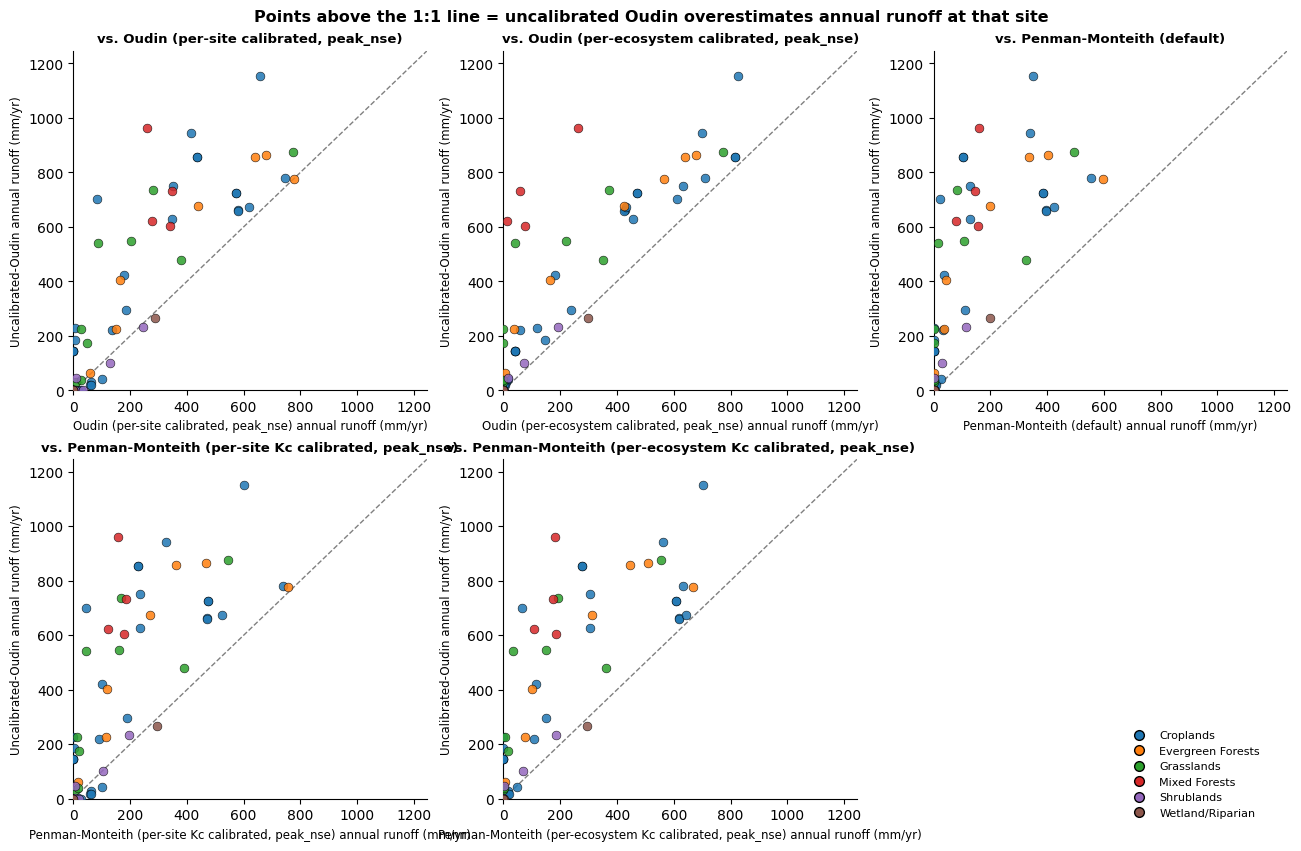

Saved to Data/runoff_implications/runoff_scatter_default_vs_alternatives.png
Sites where uncalibrated Oudin overestimates runoff vs. Oudin (per-site calibrated, peak_nse): 46 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Oudin (per-ecosystem calibrated, peak_nse): 59 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (default): 61 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (per-site Kc calibrated, peak_nse): 51 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (per-ecosystem Kc calibrated, peak_nse): 59 / 72


In [6]:
ecosystems_all = sorted(balance["ecosystem"].dropna().unique())
tab_colors = plt.cm.tab10.colors
eco_colors = {e: tab_colors[i % 10] for i, e in enumerate(ecosystems_all)}

n_alt = len(ALTERNATIVES)
ncols = min(n_alt, 3)
nrows = -(-n_alt // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
panels = [(f"runoff_{alt}", VARIANT_LABELS[alt]) for alt in ALTERNATIVES]

for ax, (col, label) in zip(axes, panels):
    for eco, grp in balance.groupby("ecosystem"):
        ax.scatter(grp[col], grp["runoff_default"], s=40, color=eco_colors.get(eco, "grey"),
                   edgecolors="k", linewidths=0.4, alpha=0.85, label=eco, zorder=3)
    lims = [0, max(balance[col].max(), balance["runoff_default"].max()) * 1.08]
    ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{label} annual runoff (mm/yr)", fontsize=8.5)
    ax.set_ylabel("Uncalibrated-Oudin annual runoff (mm/yr)", fontsize=8.5)
    ax.set_title(f"vs. {label}", fontsize=9.5, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_alt:]:
    ax.set_visible(False)

handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=7,
                      markerfacecolor=eco_colors[e], markeredgecolor="k", label=e)
           for e in ecosystems_all]
fig.legend(handles=handles, loc="lower right", ncol=1,
           bbox_to_anchor=(0.98, 0.02), fontsize=8, frameon=False)
fig.suptitle("Points above the 1:1 line = uncalibrated Oudin overestimates annual runoff at that site",
             fontsize=11.5, fontweight="bold")
plt.savefig("../Data/runoff_implications/runoff_scatter_default_vs_alternatives.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/runoff_implications/runoff_scatter_default_vs_alternatives.png")

for alt in ALTERNATIVES:
    n_above = (balance["runoff_default"] > balance[f"runoff_{alt}"]).sum()
    print(f"Sites where uncalibrated Oudin overestimates runoff vs. {VARIANT_LABELS[alt]}: "
          f"{n_above} / {len(balance)}")

### Seasonality of the runoff-overestimation bias

The annual-total comparison above shows *how much* switching methods would change
mean annual runoff, but says nothing about *when in the year* that correction would
actually apply. If uncalibrated Oudin's AET underestimation is concentrated in the
months that already produce the most runoff (e.g. spring snowmelt), the practical
consequence is larger than the annual-average framing suggests — a flood-frequency or
peak-flow estimate driven by those specific months would inherit most of the bias,
even though the *annual total* correction looks the same either way. Conversely, if
the bias is spread evenly across the year, the annual-total number already tells the
whole story.

This section repeats the same `RUNOFF`/`AET` comparison at **calendar-month**
resolution: for each site, average each calendar month's total `PPT`/`AET`/`RUNOFF`
across all 8 years (a monthly climatology), then look at how the runoff-overestimation
bias (`Δrunoff = runoff_default − runoff_alt`) and the AET bias
(`ΔAET = AET_alt − AET_default`) vary month to month, nationwide and by
ecosystem.

In [7]:
def monthly_climatology(df, label):
    """Calendar-month totals per site per year, then averaged across years ->
    one row per site per month (1-12) -- the 'typical monthly water balance'
    each variant implies at each site."""
    monthly_totals = (
        df.assign(year=df["date"].dt.year, month=df["date"].dt.month)
        .groupby(["site", "year", "month"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .sum()
    )
    out = (
        monthly_totals.groupby(["site", "month"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .mean()
        .rename(columns={
            "ppt_mm": f"ppt_{label}", "AET": f"aet_{label}", "RUNOFF": f"runoff_{label}",
        })
    )
    return out


mon = {key: monthly_climatology(df, key) for key, df in wbm.items()}

monthly = mon["default"]
for key in ALTERNATIVES:
    monthly = monthly.merge(mon[key], on=["site", "month"], how="inner")
monthly = monthly.merge(eco_lookup, on="site", how="left")

for alt in ALTERNATIVES:
    monthly[f"delta_runoff_{alt}"] = monthly["runoff_default"] - monthly[f"runoff_{alt}"]
    monthly[f"delta_aet_{alt}"]    = monthly[f"aet_{alt}"] - monthly["aet_default"]

print(f"Monthly climatology rows: {monthly.shape}  "
      f"({monthly['site'].nunique()} sites x 12 months, should be sites x 12)")
monthly.to_csv("../Data/runoff_implications/monthly_water_balance_by_site.csv", index=False)
print("Saved to Data/runoff_implications/monthly_water_balance_by_site.csv")

Monthly climatology rows: (864, 32)  (72 sites x 12 months, should be sites x 12)
Saved to Data/runoff_implications/monthly_water_balance_by_site.csv


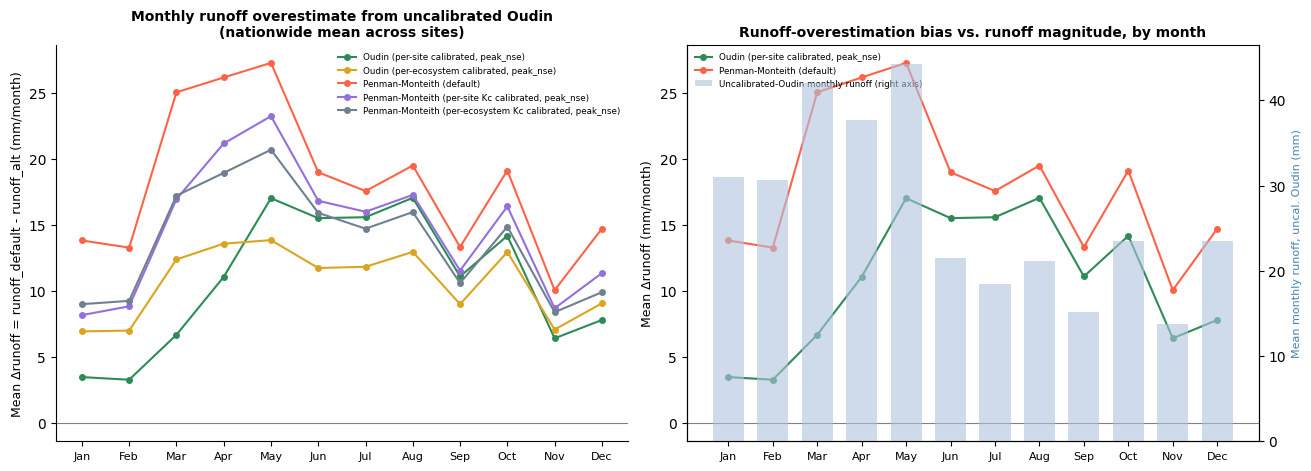

Saved to Data/runoff_implications/monthly_runoff_bias_nationwide.png

Across the 12 calendar months (nationwide mean), correlation between uncalibrated-Oudin's
own monthly runoff magnitude and the size of its overestimation bias vs. each alternative:
  runoff_default vs delta_runoff_sitecal   : r = -0.10
  runoff_default vs delta_runoff_ecocal    : r = +0.39
  runoff_default vs delta_runoff_pm        : r = +0.76
  runoff_default vs delta_runoff_pmcal     : r = +0.52
  runoff_default vs delta_runoff_pmecocal  : r = +0.59

Month with largest mean runoff (uncal. Oudin): May (44.3 mm/month)
Month with largest Δrunoff vs Oudin (per-site calibrated, peak_nse): Aug (+17.0 mm/month)
Month with largest Δrunoff vs Oudin (per-ecosystem calibrated, peak_nse): May (+13.8 mm/month)
Month with largest Δrunoff vs Penman-Monteith (default): May (+27.3 mm/month)
Month with largest Δrunoff vs Penman-Monteith (per-site Kc calibrated, peak_nse): May (+23.2 mm/month)
Month with largest Δrunoff vs Penman-Mon

In [8]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

nation_monthly = monthly.groupby("month")[
    ["runoff_default", "aet_default"]
    + [f"runoff_{a}" for a in ALTERNATIVES]
    + [f"aet_{a}" for a in ALTERNATIVES]
    + [f"delta_runoff_{a}" for a in ALTERNATIVES]
    + [f"delta_aet_{a}" for a in ALTERNATIVES]
].mean()
nation_monthly.to_csv("../Data/runoff_implications/monthly_water_balance_nationwide.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

# Panel 1: monthly runoff-overestimation bias, all five alternatives.
ax = axes[0]
for alt in ALTERNATIVES:
    ax.plot(nation_monthly.index, nation_monthly[f"delta_runoff_{alt}"],
             marker="o", markersize=4, color=ALT_COLORS[alt], label=VARIANT_LABELS[alt])
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("Mean Δrunoff = runoff_default - runoff_alt (mm/month)", fontsize=9)
ax.set_title("Monthly runoff overestimate from uncalibrated Oudin\n(nationwide mean across sites)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=6.3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Panel 2: bias overlaid on the alternative's own monthly runoff magnitude, to
# visually test whether the bias tracks the size of runoff itself.
ax = axes[1]
ax2 = ax.twinx()
ax2.bar(nation_monthly.index, nation_monthly["runoff_default"], color="lightsteelblue",
        alpha=0.6, width=0.7, zorder=1, label="Uncalibrated-Oudin monthly runoff (right axis)")
for alt in ("sitecal", "pm"):
    ax.plot(nation_monthly.index, nation_monthly[f"delta_runoff_{alt}"],
             marker="o", markersize=4, color=ALT_COLORS[alt], label=VARIANT_LABELS[alt], zorder=3)
ax.axhline(0, color="grey", linewidth=0.8, zorder=2)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("Mean Δrunoff (mm/month)", fontsize=9)
ax2.set_ylabel("Mean monthly runoff, uncal. Oudin (mm)", fontsize=8, color="steelblue")
ax.set_title("Runoff-overestimation bias vs. runoff magnitude, by month", fontsize=10, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=6.3, frameon=False, loc="upper left")
ax.spines[["top"]].set_visible(False)

plt.savefig("../Data/runoff_implications/monthly_runoff_bias_nationwide.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/runoff_implications/monthly_runoff_bias_nationwide.png")

# ── Directly test the motivating hypothesis: is the overestimation bias
# biggest in the months that already generate the most runoff? ─────────────
print("\nAcross the 12 calendar months (nationwide mean), correlation between "
      "uncalibrated-Oudin's\nown monthly runoff magnitude and the size of its "
      "overestimation bias vs. each alternative:")
for alt in ALTERNATIVES:
    corr = nation_monthly["runoff_default"].corr(nation_monthly[f"delta_runoff_{alt}"])
    print(f"  runoff_default vs delta_runoff_{alt:10s}: r = {corr:+.2f}")

peak_runoff_month = MONTH_NAMES[int(nation_monthly["runoff_default"].idxmax()) - 1]
print(f"\nMonth with largest mean runoff (uncal. Oudin): {peak_runoff_month} "
      f"({nation_monthly['runoff_default'].max():.1f} mm/month)")
for alt in ALTERNATIVES:
    worst_m = nation_monthly[f"delta_runoff_{alt}"].idxmax()
    print(f"Month with largest Δrunoff vs {VARIANT_LABELS[alt]}: "
          f"{MONTH_NAMES[int(worst_m) - 1]} ({nation_monthly[f'delta_runoff_{alt}'].max():+.1f} mm/month)")

print("\nFor context, monthly AET bias (ΔAET = AET_alt - AET_default, positive means "
      "the alternative\nadds back AET the default was missing) across the same months:")
for alt in ALTERNATIVES:
    worst_m = nation_monthly[f"delta_aet_{alt}"].idxmax()
    print(f"  Largest ΔAET vs {VARIANT_LABELS[alt]:58s}: "
          f"{MONTH_NAMES[int(worst_m) - 1]} ({nation_monthly[f'delta_aet_{alt}'].max():+.1f} mm/month)")

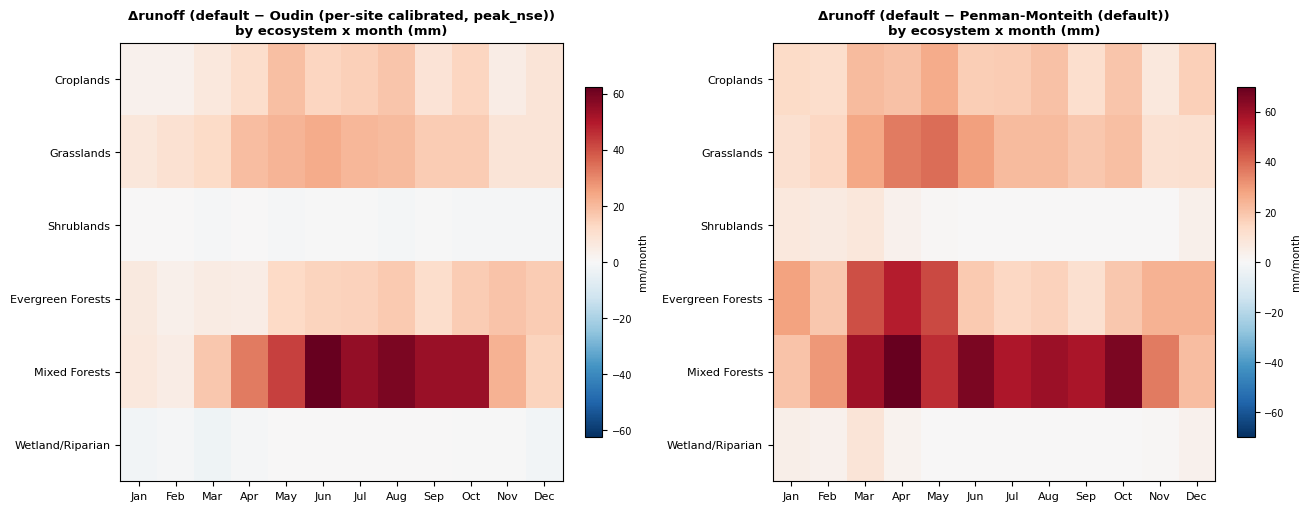

Saved to Data/runoff_implications/monthly_bias_heatmap_by_ecosystem.png

Red = uncalibrated Oudin overestimates runoff that month (positive Δrunoff); blue = it underestimates it (negative Δrunoff) relative to that alternative.


In [9]:
eco_month = (
    monthly.groupby(["ecosystem", "month"])[[f"delta_runoff_{a}" for a in ALTERNATIVES]]
    .mean()
    .reset_index()
)
eco_month.to_csv("../Data/runoff_implications/monthly_water_balance_by_ecosystem.csv", index=False)

eco_order = eco_summary["ecosystem"].tolist()  # sorted by n_sites desc, from the annual section

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, alt in zip(axes, ("sitecal", "pm")):
    pivot = (
        eco_month.pivot(index="ecosystem", columns="month", values=f"delta_runoff_{alt}")
        .reindex(eco_order)
    )
    vmax = max(abs(np.nanmin(pivot.values)), abs(np.nanmax(pivot.values)), 1)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_yticks(range(len(eco_order))); ax.set_yticklabels(eco_order, fontsize=8)
    ax.set_title(f"Δrunoff (default − {VARIANT_LABELS[alt]})\nby ecosystem x month (mm)",
                 fontsize=9.5, fontweight="bold")
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label("mm/month", fontsize=7.5)
plt.savefig("../Data/runoff_implications/monthly_bias_heatmap_by_ecosystem.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/runoff_implications/monthly_bias_heatmap_by_ecosystem.png")
print("\nRed = uncalibrated Oudin overestimates runoff that month (positive Δrunoff); "
      "blue = it underestimates it (negative Δrunoff) relative to that alternative.")

### Takeaways

**All six variants included** (n=72 sites with matched data across every variant):
default Oudin, per-site- and per-ecosystem-calibrated Oudin, default Penman-Monteith,
and per-site- and per-ecosystem-Kc-calibrated Penman-Monteith (notebook 07's
calibration was re-run with fresh gridMET data partway through this analysis — see
the note in the intro above and the staleness check in the load cell, which now finds
nothing to flag).

**Annual water balance:**
- At the annual scale, the model's own `RUNOFF` output tracks `PPT - AET` reasonably
  well but not exactly — a small positive residual (mean +15 to +17 mm/yr across all
  six variants, out of 300–1000 mm/yr typical annual precipitation) shows some water
  is retained in storage/snowpack carry-over that hasn't fully released within this
  8-year window, rather than a numerical error — the headline numbers below use the
  model's literal `RUNOFF` output directly, not the `PPT - AET` approximation.
- **Because uncalibrated Oudin underestimates AET nationwide, it correspondingly
  overestimates annual runoff** at most sites, for every alternative: per-site-cal.
  Oudin (46/72 sites, mean +129.2 mm/yr, median +64.7, +15.7%/+7.7% of precip),
  per-ecosystem-cal. Oudin (59/72, mean +128.4, median +58.1, +16.2%/+12.4%), default
  Penman-Monteith (61/72, mean +218.8, median +145.9, +27.3%/+21.9%), per-site-Kc-cal.
  Penman-Monteith (51/72, mean +176.4, median +97.2, +21.0%/+13.5%), and
  per-ecosystem-Kc-cal. Penman-Monteith (59/72, mean +165.5, median +82.2,
  +21.7%/+12.6%).
- **Kc calibration shrinks Penman-Monteith's runoff correction but doesn't eliminate
  it:** default Penman-Monteith implies the single largest correction of the six
  (+27.3% of precipitation), and calibrating its `Kc` (either per-site or
  per-ecosystem) pulls that down to roughly +21–22% — still larger than either
  calibrated-Oudin correction, consistent with notebook 08's finding that
  Penman-Monteith runs less negatively biased (i.e. higher AET) than calibrated Oudin
  even after calibration.
- The size of the correction varies a lot by ecosystem: largest in Mixed Forests
  (+42–64% of precipitation across variants) and Evergreen Forests (+21–48%),
  smallest — and even reversed for several variants — in Shrublands and
  Wetland/Riparian (−2% to +9%), where AET barely changes between variants at all
  (consistent with notebook 08's finding that calibration doesn't help much in those
  ecosystems either).

**Seasonality — does the bias track when runoff is greatest?**
The motivating hypothesis was that AET underestimation, and the resulting runoff
overestimation, would be worst in the months that already generate the most runoff.
Testing this via the correlation (across the 12 calendar months, nationwide mean)
between uncalibrated Oudin's own monthly runoff and each alternative's Δrunoff bias,
the answer is **method-dependent, and calibration matters**:
- **Penman-Monteith variants show the strongest seasonal concentration**, default
  Penman-Monteith most of all (r = +0.76), with per-site- and per-ecosystem-Kc
  calibration reducing but not eliminating it (r = +0.52 and +0.59 respectively). All
  three peak in **May** — the same month uncalibrated Oudin's own runoff peaks
  (44.3 mm/month) — meaning Penman-Monteith's correction (calibrated or not) is
  concentrated almost exactly where a peak-flow or wet-season water-availability
  analysis would be most sensitive to it, not spread evenly across the year.
- **Per-ecosystem-calibrated Oudin** shows a moderate positive relationship
  (r = +0.39), also peaking in May (+13.8 mm), but less concentrated there than any
  Penman-Monteith variant.
- **Per-site-calibrated Oudin does not follow the hypothesis at all**: the
  correlation is essentially flat/slightly negative (r = −0.10), and its largest
  monthly correction actually falls in **August** (+17.0 mm), not May — this fit
  distributes its correction more evenly across the year rather than concentrating it
  in the peak-runoff season.
- Practical implication: if the WBM's runoff output is being used for a peak-flow or
  wet-season question specifically (rather than an annual total), the choice of AET
  method matters more than the annual-scale comparison above suggests on its own —
  every Penman-Monteith variant concentrates its correction in the same high-runoff
  month, while per-site-calibrated Oudin spreads its correction out and peaks in a
  comparatively low-runoff month instead.
- These correlations use only 12 data points (nationwide monthly means) each, so
  should be read as a first-order seasonal signal, not a rigorously tested
  statistical result — the ecosystem-by-month heatmap above is the more granular view
  if a specific park's seasonal pattern is the actual quantity of interest.

**Follow-up:** this notebook's seasonal section uses each variant's own multi-year
monthly climatology, nationwide-averaged; a site-level (rather than nationwide-mean)
version of the same correlation check would show whether the May/August seasonal
split found here holds everywhere or is driven by a subset of high-runoff sites.